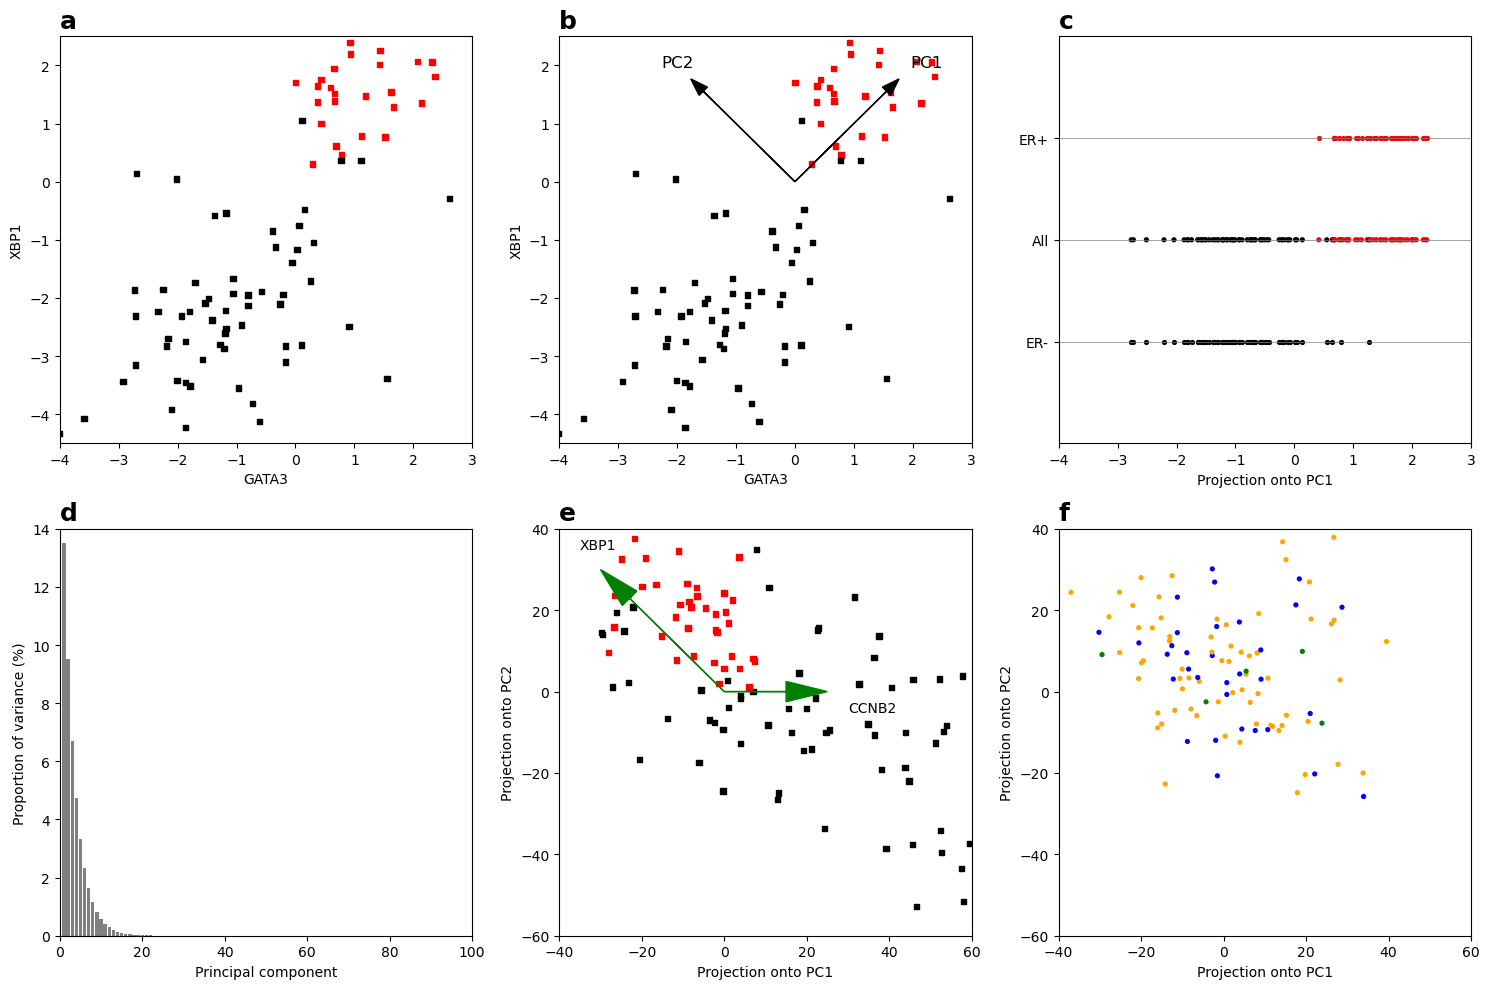

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

n_samples = 105
labels = np.array([0] * 63 + [1] * 42)  # 0=ER-, 1=ER+
np.random.shuffle(labels)

gata3 = np.zeros(n_samples)
xbp1 = np.zeros(n_samples)

for i in range(n_samples):
    if labels[i] == 1:  # ER+ (red)
        gata3[i] = np.random.normal(1.2, 0.7)
        xbp1[i] = np.random.normal(1.2, 0.7)
    else:  # ER- (black)
        gata3[i] = np.random.normal(-1.0, 1.3)
        xbp1[i] = np.random.normal(-1.5, 1.2)

xbp1 += 0.6 * gata3 + np.random.normal(0, 0.4, n_samples)

X = np.column_stack((gata3, xbp1))
X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_std)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
ax = axes[0, 0]
ax.scatter(X[:, 0], X[:, 1],
           c=['red' if c == 1 else 'black' for c in labels],
           marker='s', s=15)
ax.set_xlabel('GATA3')
ax.set_ylabel('XBP1')
ax.set_title('a', fontsize=18, loc='left', weight='bold')
ax.set_xlim(-4, 3)
ax.set_ylim(-4.5, 2.5)
ax = axes[0, 1]
ax.scatter(X[:, 0], X[:, 1],
           c=['red' if c == 1 else 'black' for c in labels],
           marker='s', s=15)

evecs = pca.components_
if evecs[0, 0] < 0: evecs[0] = -evecs[0]
if evecs[1, 1] < 0: evecs[1] = -evecs[1]

scale = 2.5
for i, vec in enumerate(evecs):
    ax.arrow(0, 0, scale * vec[0], scale * vec[1],
             head_width=0.2, head_length=0.3, fc='black', ec='black', length_includes_head=True)
    ax.text(scale * vec[0] + (-0.5 if i == 1 else 0.2), scale * vec[1] + 0.2, f"PC{i+1}", fontsize=12)

ax.set_xlabel('GATA3')
ax.set_ylabel('XBP1')
ax.set_title('b', fontsize=18, loc='left', weight='bold')
ax.set_xlim(-4, 3)
ax.set_ylim(-4.5, 2.5)
ax = axes[0, 2]
y_levels = {'All': 0, 'ER-': -0.5, 'ER+': 0.5}
for y in y_levels.values():
    ax.axhline(y=y, color='gray', linestyle='-', linewidth=0.5)

ax.scatter(pcs[:, 0], np.full(n_samples, y_levels['All']),
           c=['red' if c == 1 else 'black' for c in labels],
           marker='.', s=30)

ax.scatter(pcs[labels == 0, 0], np.full(sum(labels == 0), y_levels['ER-']), c='black', marker='.', s=30)
ax.scatter(pcs[labels == 1, 0], np.full(sum(labels == 1), y_levels['ER+']), c='red', marker='.', s=30)

ax.set_xlabel('Projection onto PC1')
ax.set_yticks(list(y_levels.values()))
ax.set_yticklabels(list(y_levels.keys()))
ax.set_title('c', fontsize=18, loc='left', weight='bold')
ax.set_xlim(-4, 3)
ax.set_ylim(-1, 1)
ax = axes[1, 0]
n_pcs = 100
var_ratio = np.zeros(n_pcs)
var_ratio[0] = 13.5
for i in range(1, n_pcs):
    var_ratio[i] = 13.5 * np.exp(-0.35 * i)

ax.bar(range(1, n_pcs + 1), var_ratio, color='gray', width=0.8)
ax.set_xlabel('Principal component')
ax.set_ylabel('Proportion of variance (%)')
ax.set_title('d', fontsize=18, loc='left', weight='bold')
ax.set_ylim(0, 14)
ax.set_xlim(0, n_pcs)
ax = axes[1, 1]
pc1_custom = np.zeros(n_samples)
pc2_custom = np.zeros(n_samples)
for i in range(n_samples):
    if labels[i] == 1:
        pc1_custom[i] = np.random.uniform(-30, 10)
        pc2_custom[i] = -0.8 * pc1_custom[i] + np.random.normal(15, 8)
    else:
        pc1_custom[i] = np.random.uniform(-30, 60)
        pc2_custom[i] = -0.4 * pc1_custom[i] + np.random.normal(0, 15)

ax.scatter(pc1_custom, pc2_custom,
           c=['red' if c == 1 else 'black' for c in labels],
           marker='s', s=15)
ax.arrow(0, 0, -30, 30, head_width=5, head_length=10, fc='green', ec='green', length_includes_head=True)
ax.arrow(0, 0, 25, 0, head_width=5, head_length=10, fc='green', ec='green', length_includes_head=True)
ax.text(-35, 35, "XBP1", fontsize=10)
ax.text(30, -5, "CCNB2", fontsize=10)
ax.set_xlabel('Projection onto PC1')
ax.set_ylabel('Projection onto PC2')
ax.set_title('e', fontsize=18, loc='left', weight='bold')
ax.set_xlim(-40, 60)
ax.set_ylim(-60, 40)
ax = axes[1, 2]
group_sizes = [68, 32, 5]
group_labels = np.array([0] * group_sizes[0] + [1] * group_sizes[1] + [2] * group_sizes[2])
np.random.shuffle(group_labels)
group_colors = ['orange', 'blue', 'green']
colors = [group_colors[i] for i in group_labels]

pc1_f = np.random.uniform(-40, 60, n_samples)
pc2_f = np.random.uniform(-60, 40, n_samples)

pc1_f[:68] = np.random.normal(5, 15, 68)
pc2_f[:68] = np.random.normal(0, 15, 68)
pc1_f[68:100] = np.random.normal(-15, 10, 32)
pc2_f[68:100] = np.random.normal(10, 10, 32)
pc1_f[100:] = np.random.normal(30, 5, 5)
pc2_f[100:] = np.random.normal(-20, 5, 5)

ax.scatter(pc1_f, pc2_f, c=colors, marker='.', s=30)
ax.set_xlabel('Projection onto PC1')
ax.set_ylabel('Projection onto PC2')
ax.set_title('f', fontsize=18, loc='left', weight='bold')
ax.set_xlim(-40, 60)
ax.set_ylim(-60, 40)

plt.tight_layout()
plt.savefig('pca_visualization_matched.png', dpi=300)
plt.show()
